In [1]:
import os
import random
import torch
import cv2
import numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [3]:
dataset_path = "/kaggle/input/datasets/razanbassel/shopthreting/Shop DataSet"

In [4]:
classes = ["shop lifters", "non shop lifters"]

videos = []
labels = []

for label, cls in enumerate(classes):
    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):
        if file.endswith(".mp4"):
            videos.append(os.path.join(folder, file))
            labels.append(label)

In [5]:
from sklearn.model_selection import train_test_split

train_v, test_v, train_l, test_l = train_test_split(
    videos, labels, test_size=0.15, stratify=labels, random_state=42 #نزود الtest size
)

train_v, val_v, train_l, val_l = train_test_split(
    train_v, train_l, test_size=0.15, stratify=train_l, random_state=42
)

In [6]:
class VideoDataset(Dataset):

    def __init__(self,paths,labels,frames=16,size=112,augment=False):

        self.paths = paths
        self.labels = labels
        self.frames = frames
        self.size = size
        self.augment = augment

    def __len__(self):
        return len(self.paths)

    def sample_frames(self,path):

        cap = cv2.VideoCapture(path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        idx = np.linspace(0,total-1,self.frames).astype(int) #uniform sampling

        frames = []

        for i in range(total):

            ret,frame = cap.read()
            if not ret:
                break

            if i in idx:

                frame = cv2.resize(frame,(self.size,self.size))
                frame = cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)

                if self.augment and np.random.rand() < 0.5:
                    frame = np.fliplr(frame)

                frames.append(frame)

        cap.release()

        frames = np.array(frames)
        frames = frames.transpose(3,0,1,2)
        frames = frames/255.0

        return torch.tensor(frames,dtype=torch.float)

    def __getitem__(self,idx):

        video = self.sample_frames(self.paths[idx])
        label = torch.tensor(self.labels[idx]).long()

        return video,label

In [9]:
train_dataset = VideoDataset(train_v,train_l,augment=True)
val_dataset = VideoDataset(val_v,val_l)
test_dataset = VideoDataset(test_v,test_l)

train_loader = DataLoader(train_dataset,batch_size=4,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=4)
test_loader = DataLoader(test_dataset,batch_size=4)

In [10]:
class CNN_LSTM_Model(nn.Module):
    def __init__(self, num_classes=2, hidden_size=256, num_layers=2):
        super(CNN_LSTM_Model, self).__init__()

       
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), 

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)) 
        )

        
        self.lstm = nn.LSTM(input_size=128 * 4 * 4,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=0.3)

        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x shape: (Batch, Channels, Frames, Height, Width)
        batch_size, C, frames, H, W = x.size()

        
        x = x.transpose(1, 2).contiguous().view(batch_size * frames, C, H, W)

     
        features = self.feature_extractor(x)
        features = features.view(batch_size, frames, -1) 

        
        lstm_out, (hidden, cell) = self.lstm(features)

    
        out = self.classifier(lstm_out[:, -1, :])

        return out

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [13]:
model = CNN_LSTM_Model().to(device)

#weight_class = total_samples / (num_classes × samples_in_class)
#shop lifters=855 / (2 × 324) = 1.32
#non shop lifters=855 / (2 × 531) = 0.80
class_weights = torch.tensor([1.32,0.80]).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=0.00005) # LR أقل قليلاً

In [14]:
epochs = 10

for epoch in range(epochs):

    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for videos,labels in train_loader:

        videos = videos.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(videos)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _,pred = torch.max(outputs,1)

        train_total += labels.size(0)
        train_correct += (pred==labels).sum().item()

    train_accuracy = train_correct/train_total


    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for videos,labels in val_loader:

            videos = videos.to(device)
            labels = labels.to(device)

            outputs = model(videos)

            loss = criterion(outputs,labels)

            val_loss += loss.item()

            _,pred = torch.max(outputs,1)

            val_total += labels.size(0)
            val_correct += (pred==labels).sum().item()

    val_accuracy = val_correct/val_total


    print("Epoch:",epoch,"Train Loss:",train_loss/len(train_loader),"Train Acc:",train_accuracy,"Val Loss:",val_loss/len(val_loader),"Val Acc:",val_accuracy)

    print()

Epoch: 0 Train Loss: 0.6914290820398639 Train Acc: 0.5850891410048622 Val Loss: 0.6879795832293374 Val Acc: 0.6238532110091743

Epoch: 1 Train Loss: 0.6751061551032528 Train Acc: 0.6304700162074555 Val Loss: 0.6743202901312283 Val Acc: 0.6238532110091743

Epoch: 2 Train Loss: 0.5123511469652576 Train Acc: 0.8055105348460292 Val Loss: 0.32390555686184336 Val Acc: 0.9357798165137615

Epoch: 3 Train Loss: 0.48117734765814196 Train Acc: 0.813614262560778 Val Loss: 0.7167536041566304 Val Acc: 0.6880733944954128

Epoch: 4 Train Loss: 0.37346377572224987 Train Acc: 0.8573743922204214 Val Loss: 0.4557165405047791 Val Acc: 0.8440366972477065

Epoch: 5 Train Loss: 0.2850529623368094 Train Acc: 0.9059967585089141 Val Loss: 0.19451992865651846 Val Acc: 0.9724770642201835

Epoch: 6 Train Loss: 0.21765840118450502 Train Acc: 0.9303079416531604 Val Loss: 0.17941223081600452 Val Acc: 0.963302752293578

Epoch: 7 Train Loss: 0.2004323308250957 Train Acc: 0.9303079416531604 Val Loss: 0.1695546458109415 V

In [15]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for videos,labels in test_loader:

        videos = videos.to(device)
        labels = labels.to(device)

        outputs = model(videos)

        _,pred = torch.max(outputs,1)

        total += labels.size(0)
        correct += (pred==labels).sum().item()

print("test Accuracy:",correct/total)

test Accuracy: 0.9612403100775194


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

In [20]:
def evaluate_confusion_matrix(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.show()

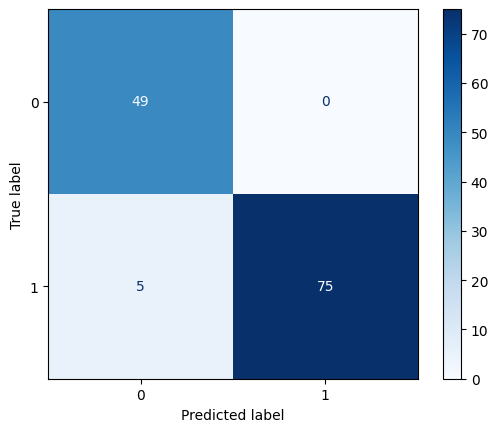

In [21]:
evaluate_confusion_matrix(model, test_loader)

In [23]:
save_path = '/kaggle/working/cnn_lstm_model.pth'

# حفظ الأوزان (State Dict) - الطريقة الأفضل والأكثر أماناً
torch.save(model.state_dict(), save_path)

print(f"Model saved successfully at: {save_path}")

Model saved successfully at: /kaggle/working/cnn_lstm_model.pth


In [25]:
def predict_single_video(model, video_path, dataset_class, classes):

    model.eval()

    temp_dataset = dataset_class(paths=[video_path], labels=[0])
    video_tensor, _ = temp_dataset[0]
    video_tensor = video_tensor.unsqueeze(0).to(device)  # (1,C,D,H,W)

    with torch.no_grad():
        outputs = model(video_tensor)
        _, pred = torch.max(outputs, 1)

    print(f"Predicted class: {classes[pred.item()]}")

In [28]:
video_path = '/kaggle/input/datasets/razanbassel/shoplifterr/shop_lifter_81.mp4'

predict_single_video(model, video_path, VideoDataset, classes)

Predicted class: shop lifters


In [27]:
video_path = '/kaggle/input/datasets/razanbassel/nonshoplifter/shop_lifter_n_13.mp4'

predict_single_video(model, video_path, VideoDataset, classes)

Predicted class: non shop lifters


In [29]:
video_path = '/kaggle/input/datasets/razanbassel/nonshoplifter2/nonthreft2.mp4'

predict_single_video(model, video_path, VideoDataset, classes)

Predicted class: non shop lifters


In [30]:
video_path = '/kaggle/input/datasets/razanbassel/threfting2/1096539685-preview.mp4'

predict_single_video(model, video_path, VideoDataset, classes)

Predicted class: shop lifters
